In [1]:
# Package activation and imports
# Activate the Julia project environment
using Pkg
Pkg.activate("..")

# Import required packages for optimal control analysis
using Plots                                 # For plotting and visualization
using OptimalControl                        # Main package for optimal control problems
using NLPModelsIpopt                        # Interface for Ipopt nonlinear solver
using OrdinaryDiffEq                        # For solving differential equations
using MINPACK                               # For nonlinear equation solving (shooting method)
using DifferentiationInterface              # For automatic differentiation
using ForwardDiff                           # Forward mode automatic differentiation
using Ipopt, Optimization, OptimizationMOI  # Additional optimization tools

  Activating project at `c:\Users\Remy_Dutto\Documents\GitHub\TurnpikeExample.jl\docs`


In [2]:
M = 1.                   
s0 = [0., 1, 0]            
xT = 0.5; yT = 0

F0(s) = [
    0.5*(s[2]^2 + s[3]^2);
    0;
    -s[3]/2
]

F1(s) = [
    0;
    1;
    -1
]

# Define the optimal control problem using OptimalControl.jl DSL
ocp(T) = @def begin
    t ∈ [0, T], time                                # Time
    s = (c, x, y) ∈ R³, state                       # State
    u ∈ R, control                                  # Control
    -M ≤ u(t) ≤ M                                   # Control's constraint
    s(0) == s0                                      # Initial state
    x(T) == xT                                      # Final state
    y(T) == yT                                      # Final state
    ṡ(t) == F0(s(t)) + u(t)*F1(s(t))                # Dynamics
    c(T) → min                                      # Cost
end

nothing; # hide

In [3]:
# Lift into (x,λ) space
H0 = Lift(F0)
H1 = Lift(F1)

# Lie bracket
H01  = @Lie {H0, H1}
H001 = @Lie {H0, H01}
H101 = @Lie {H1, H01}

# Singular control
us(s, p) = -H001(s, p) / H101(s, p)

# Pseudo-Hamiltonian
H(s,p,u) = H0(s,p) + u*H1(s,p)

nothing; # hide

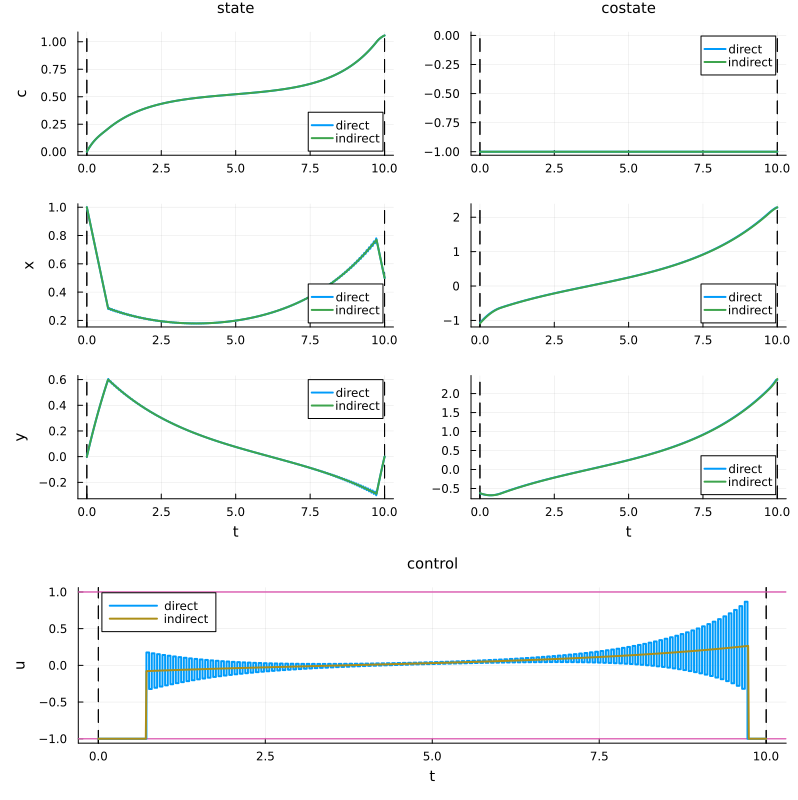

In [4]:
function sol(T)
    # Solve the optimal control problem using direct method (collocation)
    direct_sol = solve(ocp(T), display=false)
    # Flows
    ϕ0 = Flow(ocp(T), (s,p) -> -1)
    ϕ1 = Flow(ocp(T), (s,p) -> +1)
    ϕs = Flow(ocp(T), (s,p) -> us(s,p))

    # Shooting function
    function shoot!(S, ξ)
        px, py, t1, t2 = ξ
        s1, p1 = ϕ0(0, s0, [-1, px, py], t1)
        s2, p2 = ϕs(t1, s1, p1, t2)
        sf, pf = ϕ0(t2, s2, p2, T)

        S[1] = sf[2] - xT
        S[2] = sf[3] - yT
        S[3] = H1(s1, p1)
        S[4] = H01(s1, p1)
    end

    # Jacobian of the shooting function
    jshoot! = (js, ξ) -> jacobian!(shoot!, similar(ξ), js, AutoForwardDiff(), ξ)

    # Initial guess for indirect method
    p = costate(direct_sol)
    time = time_grid(direct_sol)
    u = control(direct_sol)

    p0 = p(0)
    η = 1e-3
    time_ = time[ u.(time) .≥ -1+η ]
    t1 = time_[1]; t2 = time_[end]
    ξ = [p0[2:3]..., t1, t2]

    # Resolution of S(ξ) = 0
    indirect_sol = fsolve(shoot!, jshoot!, ξ)

    px0, py0, t1, t2 = indirect_sol.x
    p0 = [-1, px0, py0]
    ϕ = ϕ0 * (t1, ϕs) * (t2, ϕ0)
    flow_sol = ϕ((0, T), s0, p0; saveat=range(0, T, 1000))

    return direct_sol, indirect_sol, flow_sol
end

T = 10.
direct_sol, sol_10, flow_10 = sol(T)

# Plot
plot(direct_sol, label="direct", size = (800, 800))
plot!(flow_10, label="indirect")

In [5]:
_, sol_20, flow_20 = sol(20)
_, sol_50, flow_50 = sol(50)

(CTModels.OCP.Solution{CTModels.OCP.UnifiedTimeGridModel{Vector{Float64}}, CTModels.OCP.TimesModel{CTModels.OCP.FixedTimeModel{Int64}, CTModels.OCP.FixedTimeModel{Int64}}, CTModels.OCP.StateModelSolution{CTModels.OCP.var"#_wrap_scalar_and_deepcopy##2#_wrap_scalar_and_deepcopy##3"{CTModels.Utils.var"#linear_interp#ctinterpolate##0"{Vector{Float64}, Vector{Vector{Float64}}}}}, CTModels.OCP.ControlModelSolution{CTModels.OCP.var"#_wrap_scalar_and_deepcopy##0#_wrap_scalar_and_deepcopy##1"{CTModels.Utils.var"#steppost_interp#ctinterpolate_constant##0"{Vector{Float64}, Vector{Vector{Float64}}}}}, CTModels.OCP.VariableModelSolution{Vector{Float64}}, CTModels.OCP.Model{CTModels.OCP.Autonomous, CTModels.OCP.TimesModel{CTModels.OCP.FixedTimeModel{Int64}, CTModels.OCP.FixedTimeModel{Int64}}, CTModels.OCP.StateModel, CTModels.OCP.ControlModel, CTModels.OCP.EmptyVariableModel, var"#fun##310#ocp##3", CTModels.OCP.MayerObjectiveModel{var"#fun##312#ocp##4"}, CTModels.OCP.ConstraintsModel{Tuple{Vector{F

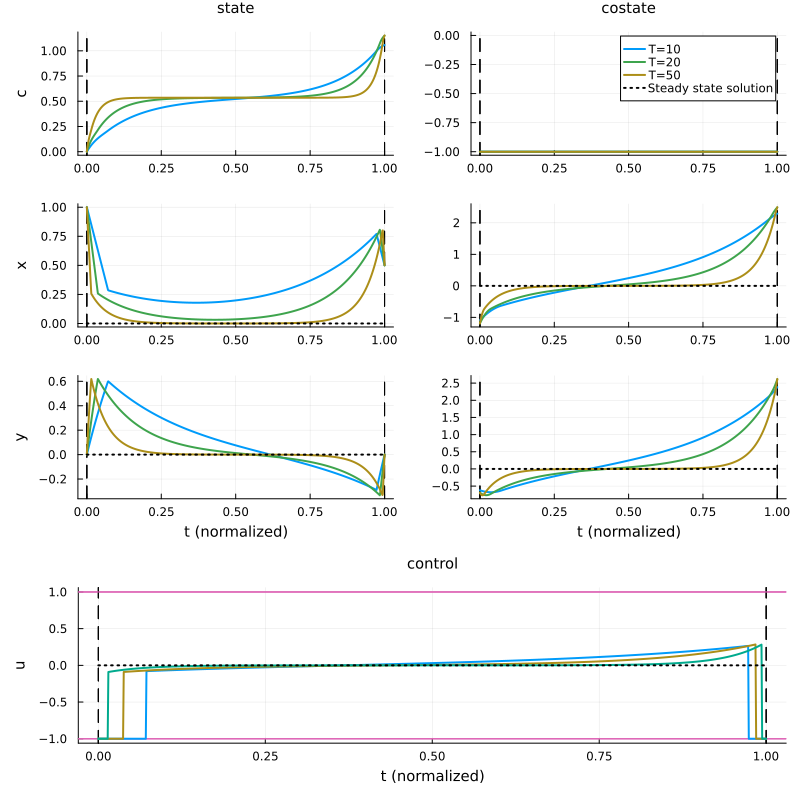

In [10]:
plt = plot(flow_10; time=:normalize, label = "T=10", size = (800, 800))
plot!(plt, flow_20; time=:normalize, label = "T=20")
plot!(plt, flow_50; time=:normalize, label = "T=50")
for i ∈ [2, 3, 5, 6, 7]
    plot!(plt, [0, 1], [0, 0], linestyle=:dot, color=:black, label="", subplot = i, lw = 2)
end
for i ∈ [1, 2, 3, 5, 6, 7]
    plot!(plt, legend = false, subplot = i)
end
plot!(plt, [0], [0], linestyle=:dot, color=:black, label="Steady state solution", subplot = 4, lw = 2)
plt


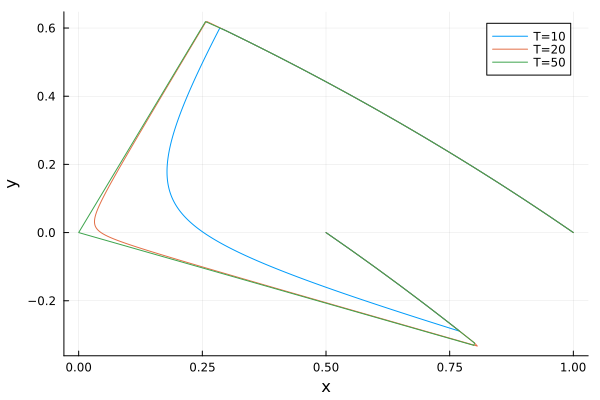

In [7]:
T = 10; time_grid_10 = range(0, T, 1000)
plot([x[2] for x ∈ state(flow_10).(time_grid_10)], [x[3] for x ∈ state(flow_10).(time_grid_10)], label="T=10", xlabel="x", ylabel="y")
T = 20; time_grid_20 = range(0, T, 1000)
plot!([x[2] for x ∈ state(flow_20).(time_grid_20)], [x[3] for x ∈ state(flow_20).(time_grid_20)], label="T=20")
T = 50; time_grid_50 = range(0, T, 1000)
plot!([x[2] for x ∈ state(flow_50).(time_grid_50)], [x[3] for x ∈ state(flow_50).(time_grid_50)], label="T=50")